# EDA 03 — Temporal & Geospatial Features

Analyse time-based patterns (Inspection Date, license dates) and
geographic distributions (Latitude, Longitude, Zip).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from helpers.data_loader import DataLoader

pd.set_option('display.max_columns', 120)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
PALETTE = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

df = pd.read_parquet(DataLoader.processed('train.parquet'))
df['Inspection Date'] = pd.to_datetime(df['Inspection Date'], errors='coerce')
print('Train shape:', df.shape)
print(f'Date range: {df["Inspection Date"].min().date()} → {df["Inspection Date"].max().date()}')

Train shape: (137176, 26)
Date range: 2010-01-04 → 2017-08-30


## 1 · Inspection volume over time

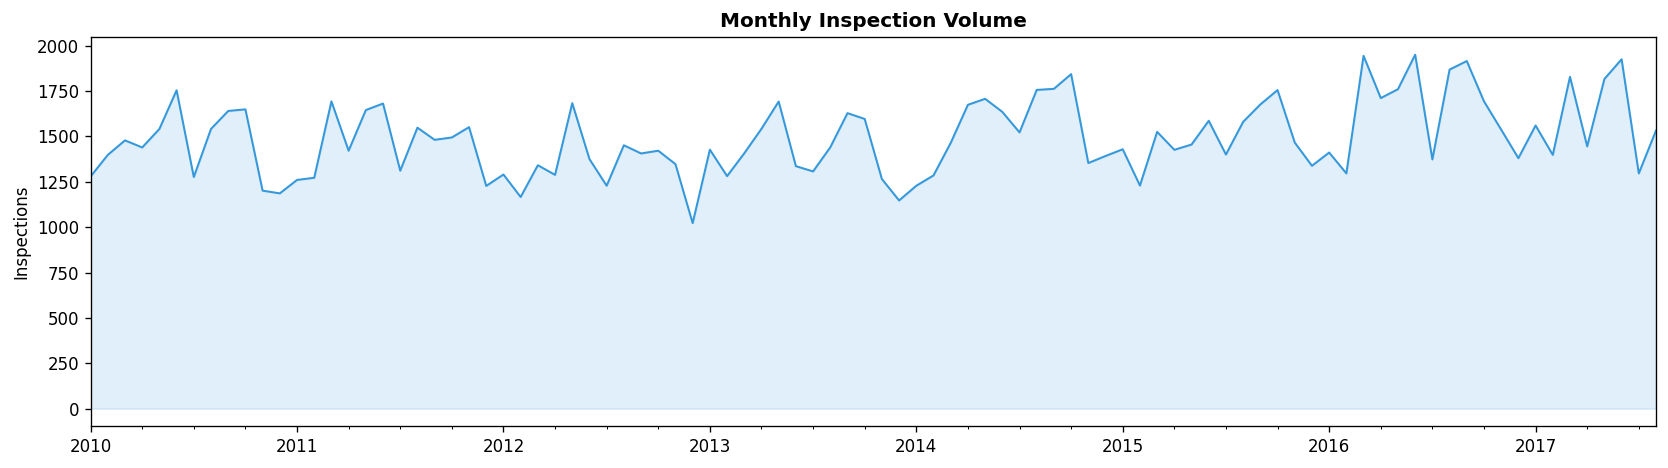

In [2]:
monthly = df.set_index('Inspection Date').resample('ME').size()

fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(ax=ax, color=PALETTE[0], linewidth=1.2)
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color=PALETTE[0])
ax.set_title('Monthly Inspection Volume', fontweight='bold')
ax.set_ylabel('Inspections')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

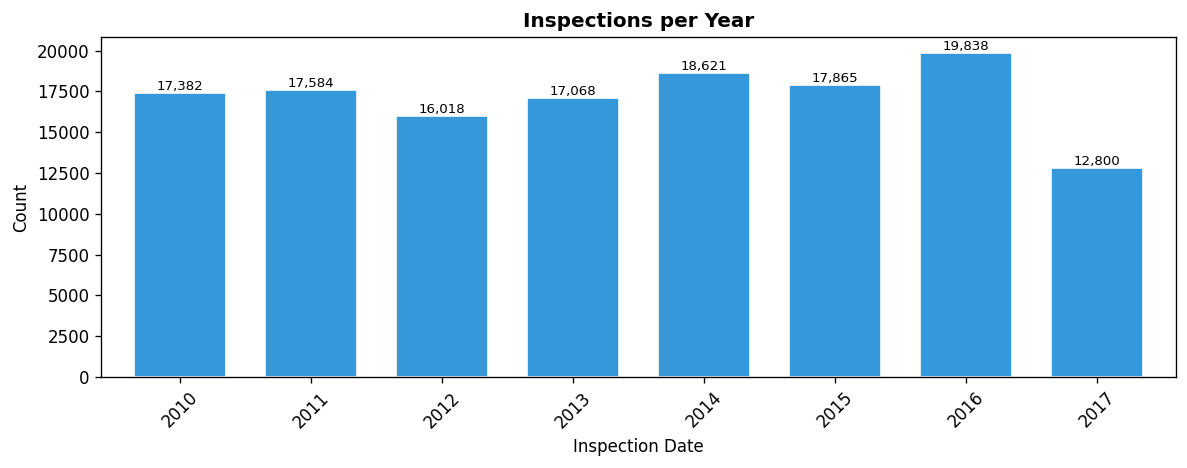

In [3]:
# Yearly breakdown
yearly = df['Inspection Date'].dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
yearly.plot.bar(ax=ax, color=PALETTE[0], edgecolor='white', width=0.7)
ax.set_title('Inspections per Year', fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for bar in ax.patches:
    ax.annotate(f'{int(bar.get_height()):,}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 2 · Day-of-week & month-of-year patterns

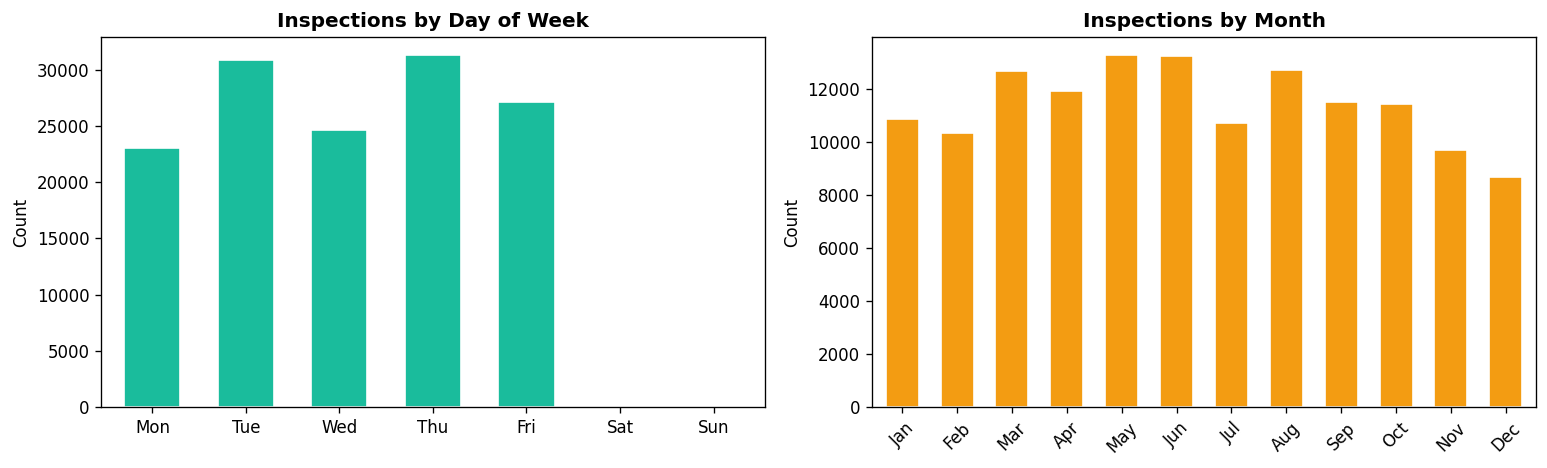

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Day of week (0=Mon .. 6=Sun)
dow = df['Inspection Date'].dt.dayofweek.value_counts().sort_index()
dow.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow.plot.bar(ax=axes[0], color=PALETTE[5], edgecolor='white', width=0.6)
axes[0].set_title('Inspections by Day of Week', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Month of year
moy = df['Inspection Date'].dt.month.value_counts().sort_index()
moy.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
moy.plot.bar(ax=axes[1], color=PALETTE[3], edgecolor='white', width=0.6)
axes[1].set_title('Inspections by Month', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3 · License date coverage

In [5]:
lic_cols = ['LICENSE TERM START DATE', 'LICENSE TERM EXPIRATION DATE']
lic_cols = [c for c in lic_cols if c in df.columns]

for col in lic_cols:
    parsed = pd.to_datetime(df[col], errors='coerce')
    null_pct = parsed.isna().mean() * 100
    print(f'{col}:')
    print(f'  Null: {parsed.isna().sum():,}  ({null_pct:.1f}%)')
    if parsed.notna().any():
        print(f'  Range: {parsed.min().date()} → {parsed.max().date()}')
    print()

LICENSE TERM START DATE:
  Null: 117,487  (85.6%)
  Range: 2000-08-16 → 2017-08-16

LICENSE TERM EXPIRATION DATE:
  Null: 6,781  (4.9%)
  Range: 1999-11-15 → 2028-06-15



## 4 · Geographic distribution

Rows with valid lat/long: 136,683 / 137,176


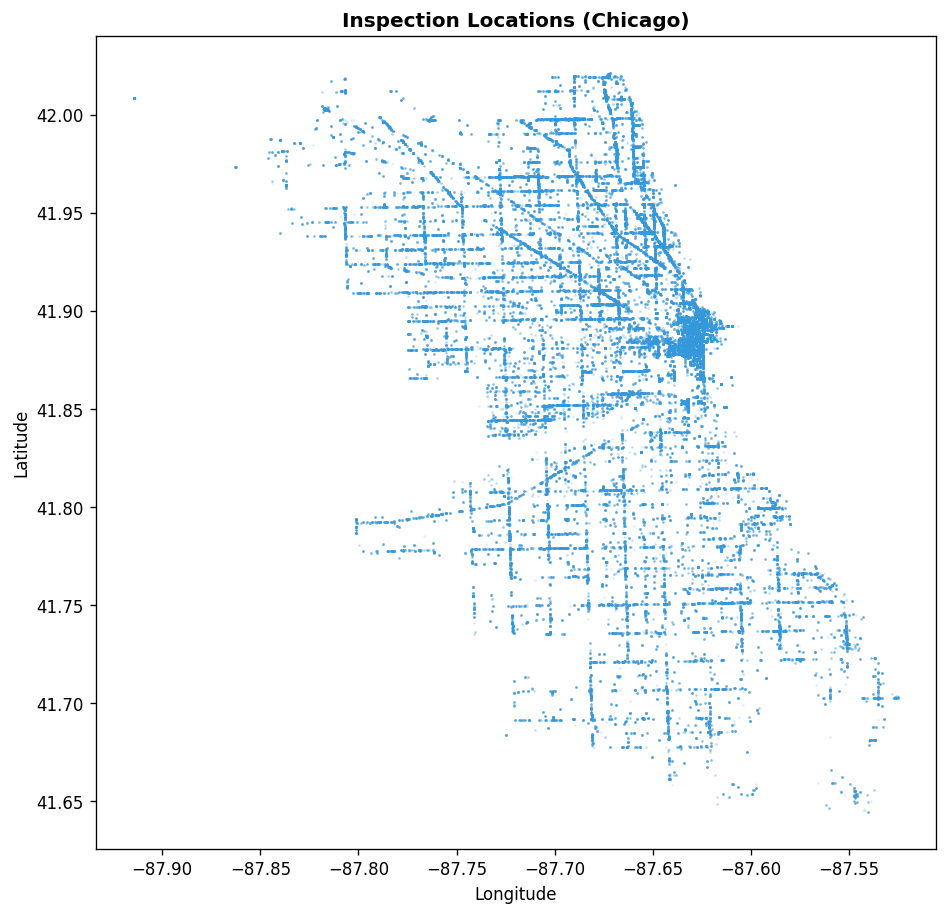

In [6]:
if {'Latitude', 'Longitude'}.issubset(df.columns):
    geo = df.dropna(subset=['Latitude', 'Longitude'])
    print(f'Rows with valid lat/long: {len(geo):,} / {len(df):,}')

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(geo['Longitude'], geo['Latitude'], s=0.3, alpha=0.15, c=PALETTE[0])
    ax.set_title('Inspection Locations (Chicago)', fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

Unique Zip codes: 100
Top 10 Zips by inspection count:


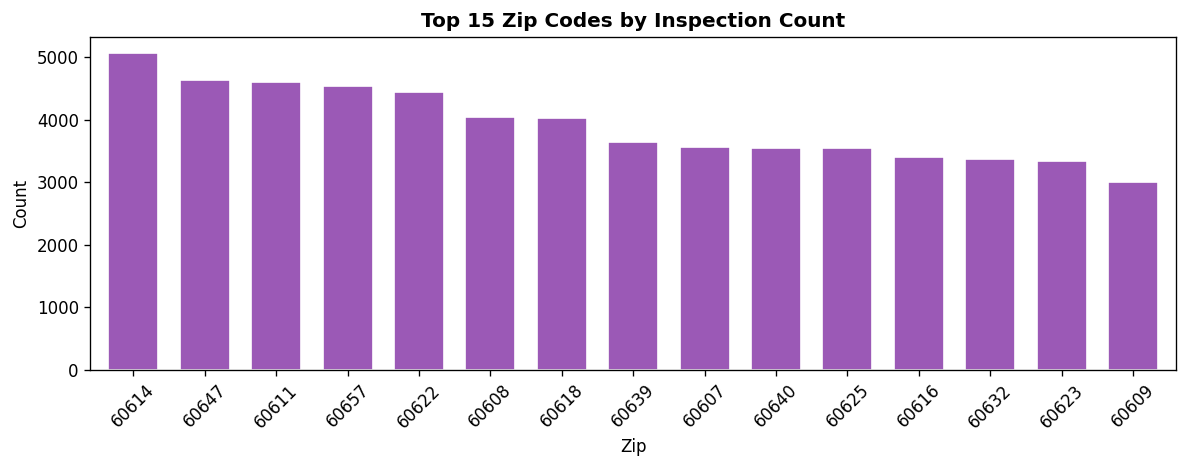

In [7]:
# Zip code analysis
if 'Zip' in df.columns:
    zip_vc = df['Zip'].dropna().astype(int).astype(str).value_counts()
    print(f'Unique Zip codes: {len(zip_vc)}')
    print(f'Top 10 Zips by inspection count:')

    fig, ax = plt.subplots(figsize=(10, 4))
    zip_vc.head(15).plot.bar(ax=ax, color=PALETTE[4], edgecolor='white', width=0.7)
    ax.set_title('Top 15 Zip Codes by Inspection Count', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 5 · Numeric feature distributions

Numeric columns: ['Inspection ID', 'License #', 'Zip', 'Latitude', 'Longitude']


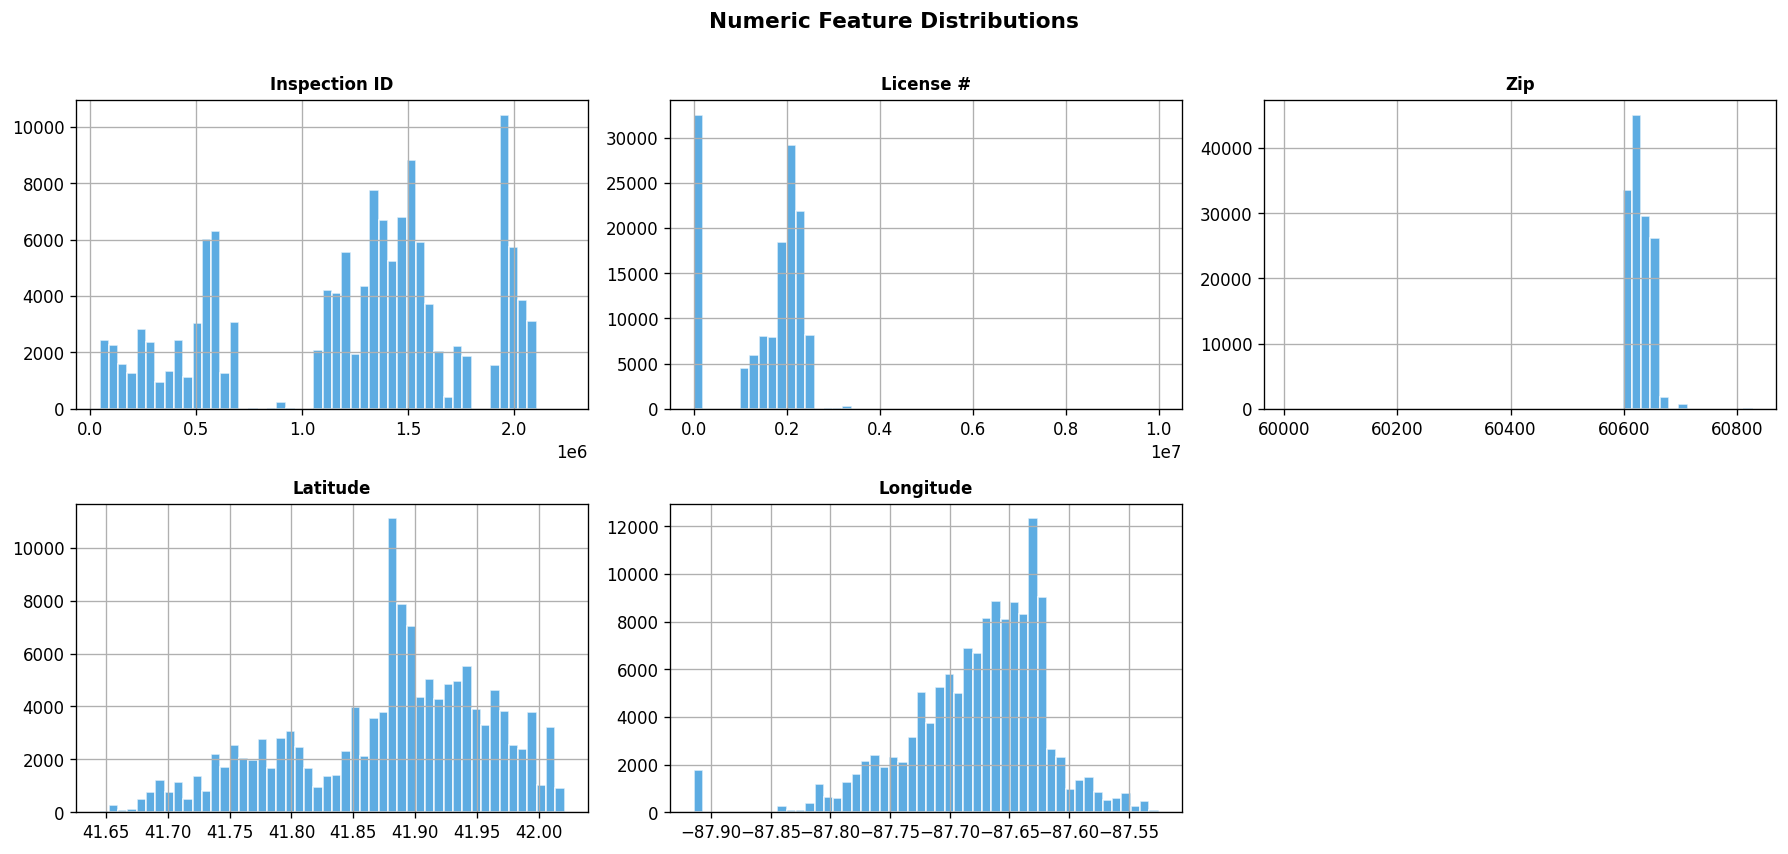

In [8]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Numeric columns: {num_cols}')

if num_cols:
    n = len(num_cols)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
    axes = np.array(axes).flatten() if n > 1 else [axes]

    for i, col in enumerate(num_cols):
        df[col].dropna().hist(ax=axes[i], bins=50, color=PALETTE[0], edgecolor='white', alpha=0.8)
        axes[i].set_title(col, fontweight='bold', fontsize=10)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Numeric Feature Distributions', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()